# Exploratory Data Analysis (EDA)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/final/cybersecurity_intrusion_data_v1.csv")
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## 1. Dataset Overview

In [5]:
df.shape

(9537, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [7]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


**Observations:**
- The dataset contains 9537 rows and 11 columns.
- Some columns contain missing values.
- The target (label) column is `attack_detected`.
- Both numerical and categorical features are present.

## 2. Label Distribution

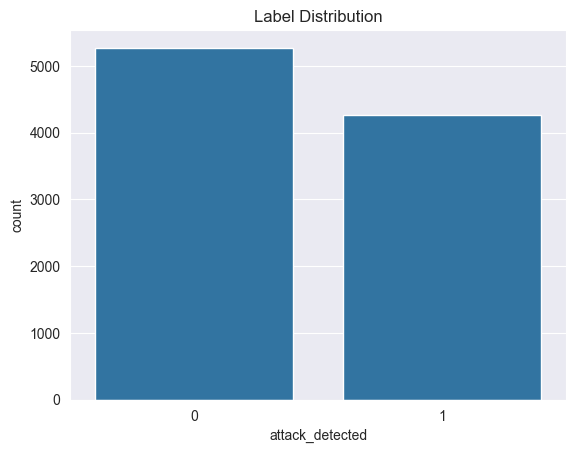

In [9]:
sns.countplot(x='attack_detected', data=df)
plt.title("Label Distribution")
plt.show()

The class distribution shows a moderate imbalance between the two labels. Non-attack instances slightly outnumber attack instances; however, the dataset remains relatively balanced overall. This level of imbalance is unlikely to severely bias model training.

## 3. Missing Values Analysis

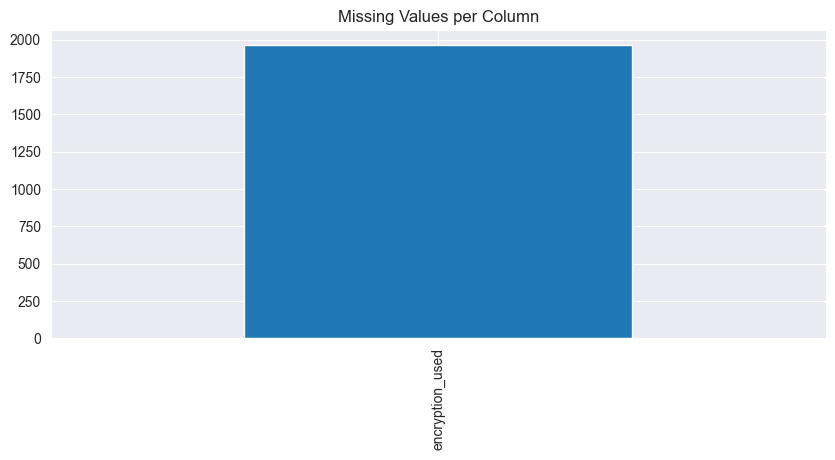

In [10]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False).plot(
    kind='bar', figsize=(10,4), title='Missing Values per Column'
)
plt.show()

The `encryption_used` feature has a large number of missing values, indicating poor data completeness. This feature may need imputation or removal before modeling.

## 4. Feature Distributions

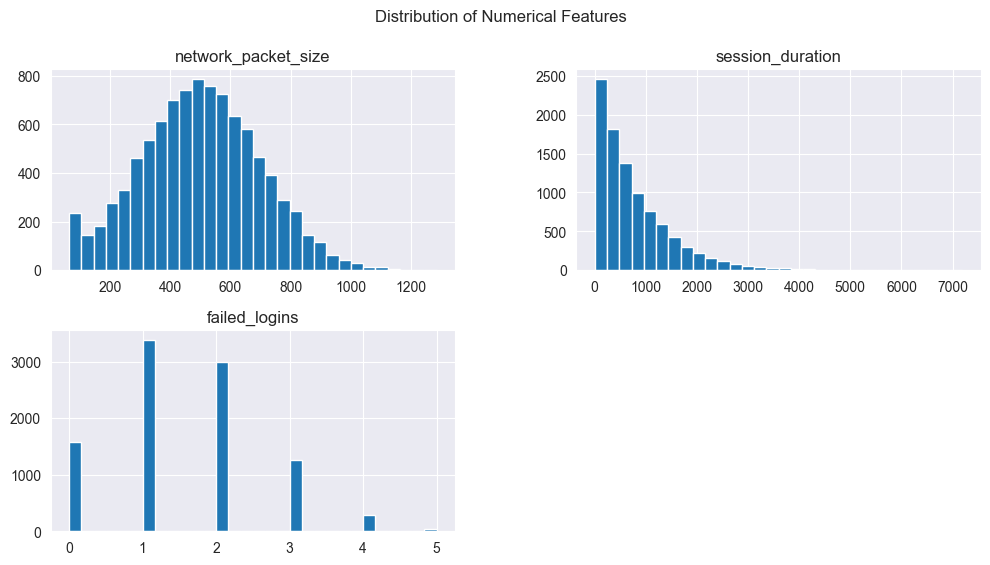

In [11]:
df[['network_packet_size','session_duration','failed_logins']].hist(
    bins=30, figsize=(12,6)
)
plt.suptitle("Distribution of Numerical Features")
plt.show()

**network_packet_size:**  
The distribution is approximately normal, indicating that most packet sizes are concentrated around the mean.

**session_duration:**  
The distribution is heavily right-skewed, showing that most sessions are short while a few last significantly longer.

**failed_logins:**  
This feature is discrete and right-skewed, with most observations having a low number of failed login attempts.

## 5. Correlation Analysis

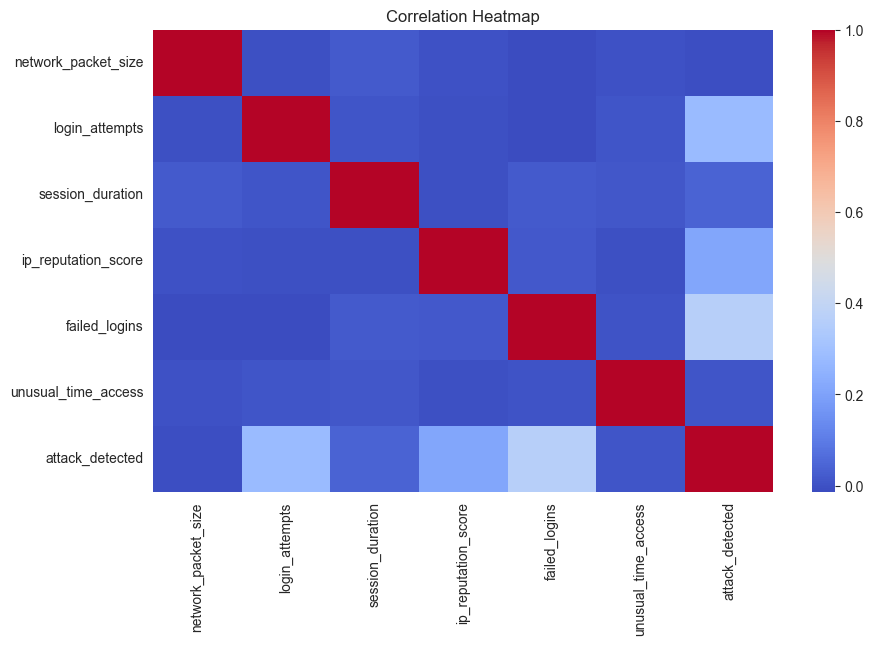

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

**Correlation Heatmap:**  
Most features show weak correlations with each other, indicating low multicollinearity. However, `attack_detected` has moderate positive correlations with `failed_logins` and `login_attempts`, suggesting these features may be informative for attack detection.

## 6. Outlier Analysis

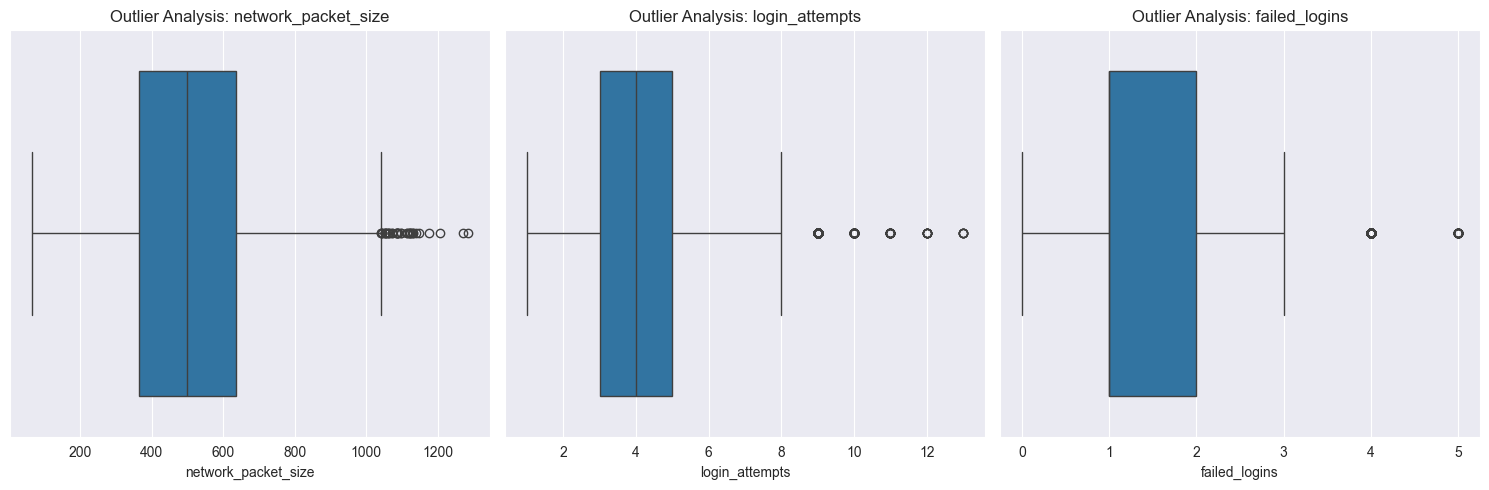

In [13]:
numeric_features = ['network_packet_size', 'login_attempts', 'failed_logins']
plt.figure(figsize=(15,5))
for i, feature in enumerate(numeric_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[feature])
    plt.title(f"Outlier Analysis: {feature}")
plt.tight_layout()
plt.show()

**network_packet_size**  
The boxplot indicates that most network packet sizes are concentrated within a moderate range, while several high-value outliers are present. These extreme values may correspond to abnormal network traffic patterns or rare events. Since such outliers can disproportionately influence model training, they should be carefully examined rather than removed blindly, especially in security-related applications.

**login_attempts**  
The majority of observations show a relatively low number of login attempts, with a small number of notable high-end outliers. These extreme cases may represent unusual or potentially malicious behavior, such as brute-force login attempts. Preserving these outliers could be beneficial for models focused on anomaly or intrusion detection.

**failed_logins**  
Most samples exhibit a low count of failed login attempts; however, a few high-value outliers are observed. These instances may indicate abnormal user behavior or compromised accounts. Therefore, these outliers may carry meaningful information and should be handled cautiously during preprocessing.

**Overall Insight**  
Outliers are consistently present across all three features. Rather than applying aggressive outlier removal, a context-aware preprocessing strategy—aligned with the problem domain and modeling objectives—is recommended.

## 7. Feature vs Label Analysis

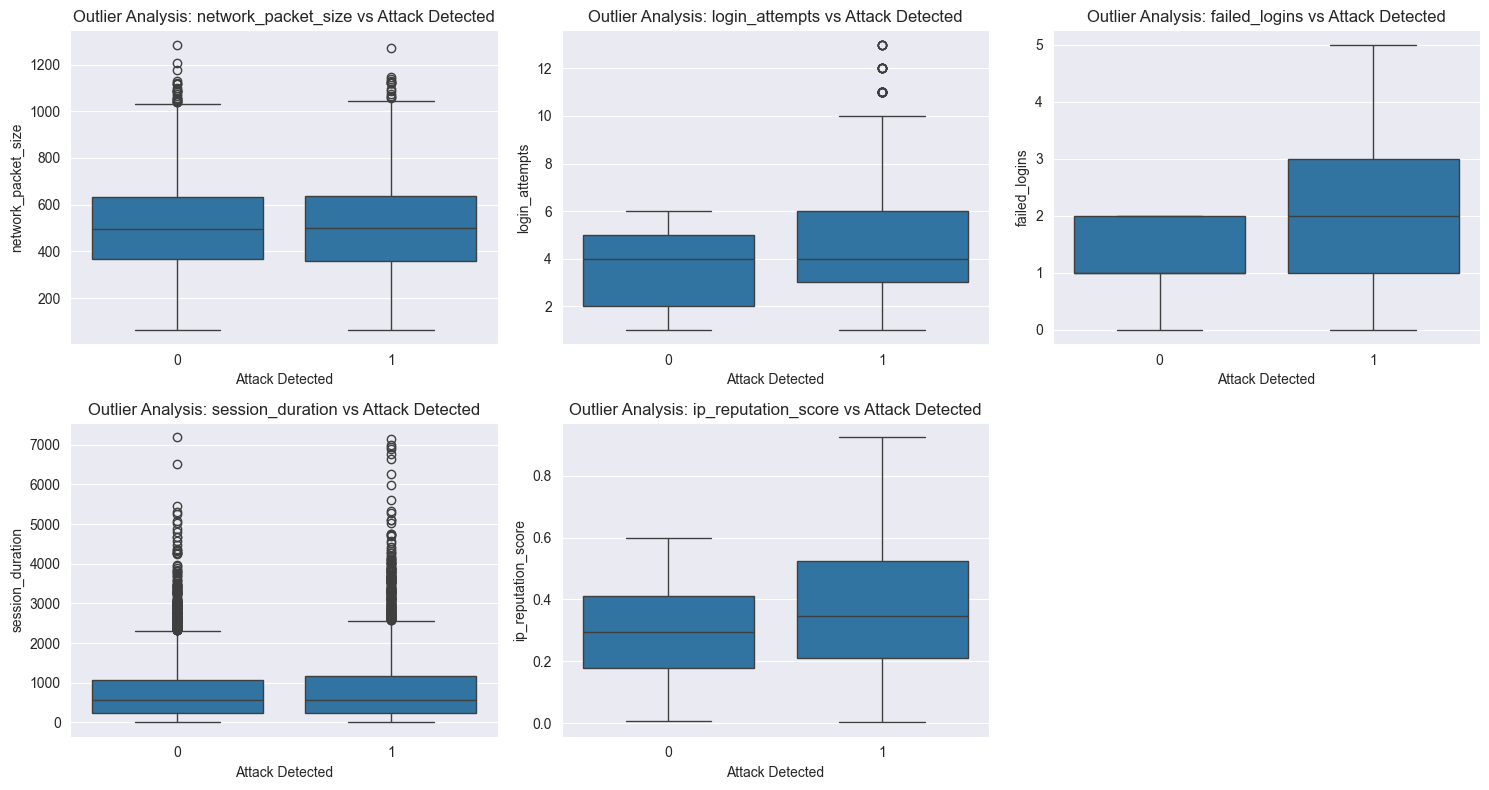

In [14]:
numeric_features= [
    'network_packet_size', 
    'login_attempts', 
    'failed_logins', 
    'session_duration',  
    'ip_reputation_score'
]

plt.figure(figsize=(15,8))

for i, feature in enumerate(numeric_features):
    plt.subplot(2, 3 , i+1)
    sns.boxplot(x='attack_detected', y=feature, data=df)
    plt.title(f"Outlier Analysis: {feature} vs Attack Detected")
    plt.xlabel("Attack Detected")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

**network_packet_size vs Attack Detected**  
The distribution of network packet sizes appears broadly similar across both normal and attack classes, with overlapping interquartile ranges. However, both classes exhibit high-value outliers, indicating that extreme packet sizes alone may not be a strong discriminator between benign and malicious traffic, though they may still contribute in combination with other features.

**login_attempts vs Attack Detected**  
Instances labeled as attacks tend to show a higher median and wider spread in the number of login attempts compared to non-attack samples. Additionally, the presence of high-end outliers is more pronounced in the attack class, suggesting that this feature carries discriminative information for identifying malicious behavior.

**failed_logins vs Attack Detected**  
The attack class demonstrates a slightly higher median number of failed login attempts and greater variability. While the overall distributions overlap, higher values of failed logins are more frequently associated with detected attacks, reinforcing the relevance of this feature for security-related modeling.

**session_duration vs Attack Detected`**  
Session duration shows substantial variability in both classes, with numerous extreme outliers. Attack-related sessions tend to exhibit longer durations and more extreme values, which may correspond to abnormal or automated interactions. This feature may benefit from transformation or robust scaling during preprocessing.

**ip_reputation_score vs Attack Detected**  
Attack samples generally display higher IP reputation scores, along with a broader distribution compared to non-attack instances. This separation suggests that IP reputation is a meaningful indicator for attack detection and may serve as a strong predictive feature.

**Overall Insight**
Several features exhibit distributional differences between attack and non-attack classes, particularly login_attempts, failed_logins, and ip_reputation_score. Although notable overlap exists, the observed shifts in medians, spread, and outlier behavior indicate their potential usefulness in supervised attack detection models.

## 8. EDA Findings

- `login_attempts`, `failed_logins`, `ip_reputation_score` → most informative for attack detection.

- `network_packet_size`, `session_duration` → presence of outliers, careful preprocessing needed.

- `encryption_used` → many missing values, requires imputation or removal before modeling.

- Correlations → mostly weak; only `login_attempts` and `failed_logins` show moderate correlation with `attack_detected`.

- Distributions → some right-skewed, some roughly normal; appropriate preprocessing recommended.